<a href="https://colab.research.google.com/github/Meheady/AI_ML/blob/main/Diabetes_detection_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

In [2]:
data = pd.read_csv('/content/diabetes.csv')

print("First 5 row data:")
print(data.head())


First 5 row data:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [3]:
print("Dataset Shape:", data.shape)

Dataset Shape: (768, 9)


In [5]:
print("Dataset Info:")
print(data.info())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [4]:
print("Dataset Description:")
print(data.describe())

Dataset Description:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000

In [7]:
print("Checking Missing Values:")
print(data.isnull().sum())

Checking Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [9]:
print("Class Distrubution:")
print(data['Outcome'].value_counts())

Class Distrubution:
Outcome
0    500
1    268
Name: count, dtype: int64


# I see dataset is imbalance

In [14]:
# check 0 in some biological features

zero_features = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("Number of zero in the features:")

for feature in zero_features:
  print(f"{feature}: {len(data.loc[data[feature] == 0])}")



Number of zero in the features:
Glucose: 5
BloodPressure: 35
SkinThickness: 227
Insulin: 374
BMI: 11


In [11]:
print(data['Glucose'].skew())

0.17375350179188992


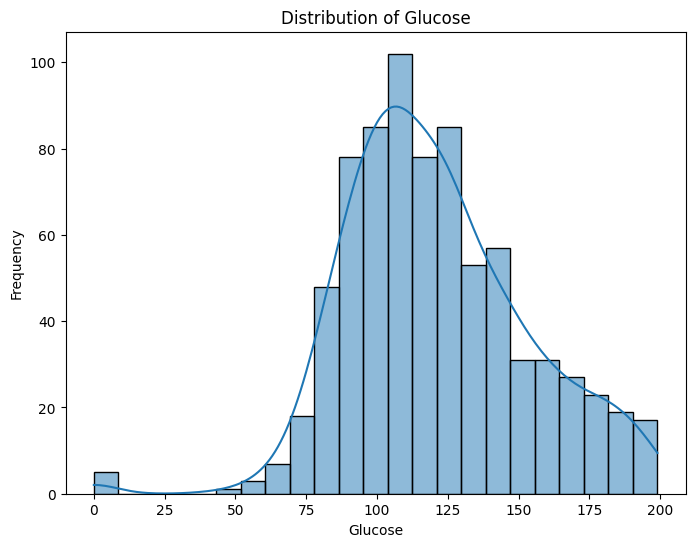

In [12]:
plt.figure(figsize=(8, 6))
sns.histplot(data['Glucose'], kde=True)
plt.title('Distribution of Glucose')
plt.xlabel('Glucose')
plt.ylabel('Frequency')
plt.show()

In [16]:

#replate zero with nan and then with mean value

data[zero_features] = data[zero_features].replace(0, np.nan)

print(data.isnull().sum())

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [18]:
data.fillna(data.mean(),inplace=True)

print(data.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [19]:
# split feature and target

x = data.drop('Outcome', axis=1)
y = data['Outcome']

In [20]:
# split data into train test

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [21]:
# featture scaling

scaler = StandardScaler()

x_train_scale = scaler.fit_transform(x_train)
x_test_scale = scaler.transform(x_test)

In [27]:

#init models

modelsInit = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100)
}

In [36]:
 # train and evalue each model

results= {}

for name, model in modelsInit.items():
  print(f"\n{'-'*50}")
  print("Training", name, "...")

    # Scale data for specific model that need it
  if name in ['Logistic Regression', 'K-Nearest Neighbors']:
        X_train_used = x_train_scale
        X_test_used = x_test_scale
  else:
        X_train_used = x_train
        X_test_used = x_test

    # Train model
  model.fit(X_train_used, y_train)

    # predictions
  y_pred = model.predict(X_test_used)

  y_pred_proba = model.predict_proba(x_test_scale)[:, 1] if hasattr(model, 'predict_proba') else None


  # calculate matrix

  cm = confusion_matrix(y_test, y_pred)
  cr = classification_report(y_test, y_pred, output_dict=True)

  # evalution store in result variable

  results[name] = {
        'classifier': model,
        'confusion_matrix': cm,
        'precision': cr['weighted avg']['precision'],
        'recall': cr['weighted avg']['recall'],
        'f1-score': cr['weighted avg']['f1-score'],
        'accuracy': cr['accuracy'],
        'y_pred_proba': y_pred_proba,
  }
  print(f"Accuracy: {results[name]['accuracy']:.4f}")
  print(f"Precision: {results[name]['precision']:.4f}")
  print(f"Recall: {results[name]['recall']:.4f}")
  print(f"F1-Score: {results[name]['f1-score']:.4f}")




--------------------------------------------------
Training Logistic Regression ...
Accuracy: 0.7532
Precision: 0.7499
Recall: 0.7532
F1-Score: 0.7510

--------------------------------------------------
Training K-Nearest Neighbors ...
Accuracy: 0.7468
Precision: 0.7624
Recall: 0.7468
F1-Score: 0.7508

--------------------------------------------------
Training Decision Tree ...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.7208
Precision: 0.7219
Recall: 0.7208
F1-Score: 0.7213

--------------------------------------------------
Training Random Forest ...
Accuracy: 0.7532
Precision: 0.7532
Recall: 0.7532
F1-Score: 0.7532


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
